# **03_Modelo_predictivo**

Desarrollado por: Ing. M. WaraLópez L.

#### Modelo Predictivo de la Salud de la Batería
##### Objetivo
Desarrollar un modelo de Machine Learning capaz de estimar la salud de una batería utilizando variables relacionadas con su uso diario, temperatura, ciclos de carga y consumo energético.
Este modelo busca demostrar el flujo completo de un proyecto de ciencia de datos, desde la preparación de los datos hasta la evaluación del modelo.

### Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)

In [2]:
sns.set_theme(style="whitegrid", palette="viridis")

### Carga de dataset

In [3]:
df = pd.read_csv('dataset_limpio_baterias.csv')

In [4]:
df["Usuario_Gamer"] = df["Usuario_Gamer"].astype("object")

In [5]:
df.head()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
0,5.0,9.797617,0,57884,1267.000000,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9.0,7.101557,0,63824,1166.109786,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9.0,10.085255,0,79414,1500.000000,64.640516,52.238349,87.853504,32.122879,63343.419989,79.763543
3,5.0,7.946047,0,61142,1153.000000,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,4.0,9.628460,0,50956,589.847345,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


### Resumen general del dataset

In [6]:
df.shape

(1210, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Edad_Bateria              1210 non-null   float64
 1   Horas_Uso_Diario          1210 non-null   float64
 2   Usuario_Gamer             1210 non-null   object 
 3   Capacidad_Diseño          1210 non-null   int64  
 4   Ciclos_Carga              1210 non-null   float64
 5   Uso_CPU                   1210 non-null   float64
 6   Uso_GPU                   1210 non-null   float64
 7   Consumo_Energia           1210 non-null   float64
 8   Temperatura_Promedio      1210 non-null   float64
 9   Capacidad_Carga_Completa  1210 non-null   float64
 10  Salud_Bateria             1210 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 104.1+ KB


In [8]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000
mean,4.342149,6.446395,62007.465289,985.651833,49.825246,37.014823,68.815020,30.476204,51525.157736,82.769920
std,2.797605,3.147934,10109.535266,521.046015,17.418638,16.283369,21.279336,2.438592,11564.107024,10.166849
min,0.000000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,23.105802,28181.020459,38.804005
25%,2.000000,3.726446,53260.250000,539.750000,36.432784,25.892769,52.904795,29.056738,42533.572906,75.314308
50%,4.000000,6.336366,61782.500000,1147.000000,49.918823,35.230937,67.836532,30.420018,51310.300033,81.186962
75%,7.000000,9.165856,70701.000000,1500.000000,61.170324,43.937879,83.433036,31.926168,60073.056633,91.349256
max,9.000000,11.986722,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,78634.214027,100.000000


In [9]:
print("Dimensiones finales:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

Dimensiones finales: (1210, 11)
Valores nulos: 0
Duplicados: 0


### Correlación de variables

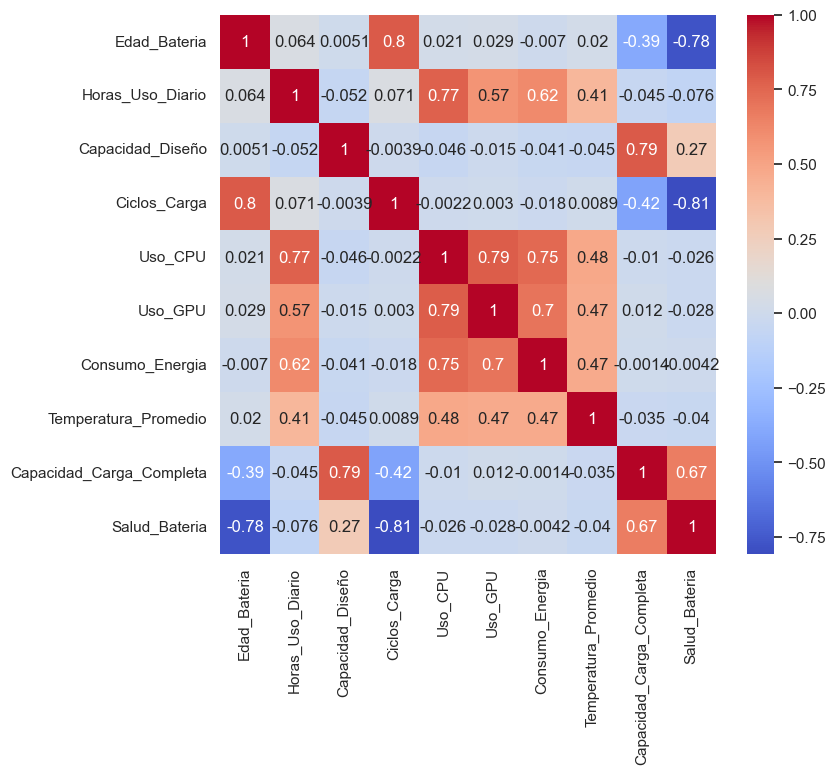

In [10]:
correlacion = df.corr(numeric_only=True)
plt.figure(figsize=(8,7))
sns.heatmap(correlacion,annot=True,cmap="coolwarm")
plt.show()

In [11]:
# Correlación de todas las variables con la variable objetivo
correlacion_target = df.corr(numeric_only=True)["Salud_Bateria"].sort_values(ascending=False)

print("Correlación con Salud_Bateria:")
print(correlacion_target)

Correlación con Salud_Bateria:
Salud_Bateria               1.000000
Capacidad_Carga_Completa    0.668381
Capacidad_Diseño            0.273595
Consumo_Energia            -0.004242
Uso_CPU                    -0.025641
Uso_GPU                    -0.028234
Temperatura_Promedio       -0.040385
Horas_Uso_Diario           -0.076377
Edad_Bateria               -0.775465
Ciclos_Carga               -0.805939
Name: Salud_Bateria, dtype: float64


### Selección de variables

In [12]:
X = df.drop(columns="Salud_Bateria")
y = df["Salud_Bateria"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (968, 10)
Prueba: (242, 10)


### Entrenar un modelo de Regresión Lineal

In [14]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = modelo.predict(X_test)

In [16]:
predicciones = X_test.copy()
predicciones["Real"] = y_test.values
predicciones["Predicción"] = y_pred
predicciones["Error"] = predicciones["Real"] - predicciones["Predicción"]

predicciones.head(10)

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Real,Predicción,Error
101,6.0,9.790738,0,45788,1438.000000,49.918823,42.161519,79.377001,30.420018,30873.303564,68.539404,70.567055,-2.027650
432,9.0,3.652817,0,59110,1500.000000,30.966810,35.230937,55.195852,28.299505,41473.871652,71.414646,70.209949,1.204697
309,8.0,2.851064,0,67258,1500.000000,35.487379,27.932181,75.414668,31.024230,51177.114569,75.771306,74.392449,1.378857
109,4.0,1.655791,0,66618,259.000000,49.918823,15.203123,26.657748,30.420018,63338.664479,93.118659,92.878461,0.240198
652,2.0,9.973199,0,49332,507.000000,49.918823,38.884137,61.200874,30.514015,45172.792256,92.185924,87.150727,5.035197
943,0.0,8.925024,0,63657,1500.000000,49.918823,41.814831,95.776187,30.420018,54035.614072,85.342116,84.555412,0.786704
231,5.0,3.306593,0,78725,1207.000000,23.137296,12.314179,35.966529,26.336451,67626.108200,82.832422,85.736743,-2.904321
49,2.0,10.263819,0,55067,1249.129060,49.918823,45.801862,49.945718,33.671389,49312.814690,88.304628,82.770168,5.534460
1040,3.0,5.900696,0,49114,1196.878059,49.475469,29.716118,79.610013,26.844640,40258.667892,80.489439,79.377163,1.112277
1187,2.0,9.745127,0,74377,545.000000,70.450306,51.403417,79.018582,33.595965,68226.001437,92.449345,94.054325,-1.604980


In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 2.774
RMSE: 4.543
R²  : 0.814


### Random Forest

In [18]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
print("Random Forest")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"R²  : {r2_score(y_test, y_pred_rf):.3f}")

Random Forest
MAE : 1.967
RMSE: 2.959
R²  : 0.921


### K-Nearest Neighbors (KNN)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [22]:
print("KNN")
print(f"MAE : {mean_absolute_error(y_test, y_pred_knn):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.3f}")
print(f"R²  : {r2_score(y_test, y_pred_knn):.3f}")

KNN
MAE : 2.713
RMSE: 4.871
R²  : 0.786


### Árbol de Decisión

In [23]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [24]:
print("Decision Tree")
print(f"MAE : {mean_absolute_error(y_test, y_pred_tree):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_tree)):.3f}")
print(f"R²  : {r2_score(y_test, y_pred_tree):.3f}")

Decision Tree
MAE : 2.697
RMSE: 4.270
R²  : 0.836


### Comparación de todos los modelos

In [25]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "KNN", "Decision Tree"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_knn),
        mean_absolute_error(y_test, y_pred_tree)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn)),
        np.sqrt(mean_squared_error(y_test, y_pred_tree))
   ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_knn),
        r2_score(y_test, y_pred_tree)
     ]
})

resultados = resultados.sort_values("R2", ascending=False)
resultados

,Modelo,MAE,RMSE,R2
1,Random Forest,1.966860,2.959091,0.921048
3,Decision Tree,2.697234,4.270369,0.835572
0,Regresión Lineal,2.773791,4.543145,0.813895
2,KNN,2.712951,4.870829,0.786080


## Selección del modelo final

Después de comparar diferentes algoritmos de regresión, se seleccionó Random Forest Regressor como modelo final debido a que presentó el menor error de predicción y el mayor coeficiente de determinación (R²).

El modelo obtuvo un R² de 0.921, indicando que logra explicar aproximadamente el 92% del comportamiento de la salud de la batería.

Además, presentó un error promedio cercano a 2 puntos porcentuales (MAE), lo cual representa una precisión adecuada para estimaciones de estado de batería.

### Importancia de las variables

In [26]:
importancia_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancia_rf = importancia_rf.sort_values("Importancia", ascending=False)

print(importancia_rf)

                   Variable  Importancia
0              Edad_Bateria     0.367889
4              Ciclos_Carga     0.355741
9  Capacidad_Carga_Completa     0.208424
3          Capacidad_Diseño     0.041818
1          Horas_Uso_Diario     0.005594
5                   Uso_CPU     0.005387
8      Temperatura_Promedio     0.005089
7           Consumo_Energia     0.004963
6                   Uso_GPU     0.004904
2             Usuario_Gamer     0.000191


In [27]:
importancia_rf["Porcentaje"] = importancia_rf["Importancia"] * 100
importancia_rf

,Variable,Importancia,Porcentaje
0,Edad_Bateria,0.367889,36.788909
4,Ciclos_Carga,0.355741,35.574089
9,Capacidad_Carga_Completa,0.208424,20.842360
3,Capacidad_Diseño,0.041818,4.181801
1,Horas_Uso_Diario,0.005594,0.559432
5,Uso_CPU,0.005387,0.538670
8,Temperatura_Promedio,0.005089,0.508851
7,Consumo_Energia,0.004963,0.496328
6,Uso_GPU,0.004904,0.490433
2,Usuario_Gamer,0.000191,0.019126


In [28]:
importancia_rf.head(5)

,Variable,Importancia,Porcentaje
0,Edad_Bateria,0.367889,36.788909
4,Ciclos_Carga,0.355741,35.574089
9,Capacidad_Carga_Completa,0.208424,20.842360
3,Capacidad_Diseño,0.041818,4.181801
1,Horas_Uso_Diario,0.005594,0.559432


In [29]:
comparacion_variables = importancia_rf.merge(
    correlacion_target.reset_index(),
    left_on="Variable",
    right_on="index"
)

comparacion_variables = comparacion_variables.drop(columns="index")

comparacion_variables.columns = [
    "Variable",
    "Importancia_RF",
    "Porcentaje_RF",
    "Correlacion"
]
comparacion_variables

,Variable,Importancia_RF,Porcentaje_RF,Correlacion
0,Edad_Bateria,0.367889,36.788909,-0.775465
1,Ciclos_Carga,0.355741,35.574089,-0.805939
2,Capacidad_Carga_Completa,0.208424,20.842360,0.668381
3,Capacidad_Diseño,0.041818,4.181801,0.273595
4,Horas_Uso_Diario,0.005594,0.559432,-0.076377
5,Uso_CPU,0.005387,0.538670,-0.025641
6,Temperatura_Promedio,0.005089,0.508851,-0.040385
7,Consumo_Energia,0.004963,0.496328,-0.004242
8,Uso_GPU,0.004904,0.490433,-0.028234


### Predicción para un nuevo registro

In [30]:
nueva_bateria = pd.DataFrame([{
    "Edad_Bateria": 6,
    "Horas_Uso_Diario": 8.5,
    "Usuario_Gamer": 1,
    "Capacidad_Diseño": 65000,
    "Ciclos_Carga": 1200,
    "Uso_CPU": 70,
    "Uso_GPU": 55,
    "Consumo_Energia": 105,
    "Temperatura_Promedio": 34,
    "Capacidad_Carga_Completa": 47000
}])

predicciones = rf.predict(nueva_bateria)

print(f"Salud estimada de la batería: {predicciones[0]:.2f}%")

Salud estimada de la batería: 76.96%


### Conclusiones del modelo predictivo

Después de evaluar diferentes algoritmos de regresión, se seleccionó Random Forest Regressor como el modelo con mejor desempeño para estimar la salud de la batería.

El modelo obtuvo un coeficiente de determinación R² de 0.921, indicando que aproximadamente el 92% de la variabilidad de la salud de batería puede ser explicada por las variables utilizadas. Además, presentó un error promedio de predicción cercano a 2 puntos porcentuales (MAE), mostrando una adecuada capacidad predictiva para este conjunto de datos.

### Importancia de variables

El análisis de importancia generado por Random Forest permitió identificar que las variables con mayor influencia en la predicción fueron:

- Edad_Bateria, con una contribución aproximada del 36.8%.
- Ciclos_Carga, con una contribución aproximada del 35.6%.
- Capacidad_Carga_Completa, con una contribución aproximada del 20.8%.

Estas tres variables concentran más del 90% de la importancia del modelo, lo que indica que el desgaste acumulado de la batería y la capacidad disponible son los principales factores asociados con su estado de salud.

Además, estos resultados son consistentes con el análisis de correlación realizado previamente, donde los ciclos de carga y la edad de la batería presentaron una relación negativa fuerte con la salud de batería, mientras que la capacidad de carga completa mostró una relación positiva.

### Predicción de una nueva batería

Como prueba final, se realizó la predicción sobre un nuevo registro con características específicas de uso y desgaste.

El modelo estimó una salud de batería de aproximadamente 76.96%, indicando que una batería con 6 años de antigüedad, 1200 ciclos de carga y una capacidad de carga completa de 47000 mAh presenta un nivel de degradación moderado. Esta predicción demuestra la capacidad del modelo para estimar el estado de una batería a partir de sus características operativas y puede servir como base para sistemas de monitoreo y mantenimiento predictivo.

### Observación

Aunque variables como temperatura, consumo energético y uso de CPU/GPU tienen relación con el funcionamiento de una batería, el modelo determinó que su aporte individual fue bajo frente a variables directamente relacionadas con el desgaste acumulado.

Esto sugiere que para este conjunto de datos la degradación de la batería está principalmente asociada con factores de envejecimiento y ciclos de uso, más que con patrones momentáneos de consumo.